In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt


from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import VotingRegressor

from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor , GradientBoostingRegressor
from sklearn.ensemble import VotingRegressor, StackingRegressor
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from sklearn.preprocessing import MinMaxScaler

import warnings
warnings.filterwarnings("ignore")
print("ok")

ok


## Task 1: Data Loading

In [ ]:
df=pd.read_csv("/content/water_potability.csv")

df


,ph,Hardness,Solids,Chloramines,Sulfate,Conductivity,Organic_carbon,Trihalomethanes,Turbidity,Potability
0,NaN,204.890455,20791.318981,7.300212,368.516441,564.308654,10.379783,86.990970,2.963135,0
1,3.716080,129.422921,18630.057858,6.635246,NaN,592.885359,15.180013,56.329076,4.500656,0
2,8.099124,224.236259,19909.541732,9.275884,NaN,418.606213,16.868637,66.420093,3.055934,0
3,8.316766,214.373394,22018.417441,8.059332,356.886136,363.266516,18.436524,100.341674,4.628771,0
4,9.092223,181.101509,17978.986339,6.546600,310.135738,398.410813,11.558279,31.997993,4.075075,0
...,...,...,...,...,...,...,...,...,...,...
3271,4.668102,193.681735,47580.991603,7.166639,359.948574,526.424171,13.894419,66.687695,4.435821,1
3272,7.808856,193.553212,17329.802160,8.061362,NaN,392.449580,19.903225,NaN,2.798243,1
3273,9.419510,175.762646,33155.578218,7.350233,NaN,432.044783,11.039070,69.845400,3.298875,1
3274,5.126763,230.603758,11983.869376,6.303357,NaN,402.883113,11.168946,77.488213,4.708658,1


In [ ]:
df.head(20)

,ph,Hardness,Solids,Chloramines,Sulfate,Conductivity,Organic_carbon,Trihalomethanes,Turbidity,Potability
0,NaN,204.890455,20791.318981,7.300212,368.516441,564.308654,10.379783,86.990970,2.963135,0
1,3.716080,129.422921,18630.057858,6.635246,NaN,592.885359,15.180013,56.329076,4.500656,0
2,8.099124,224.236259,19909.541732,9.275884,NaN,418.606213,16.868637,66.420093,3.055934,0
3,8.316766,214.373394,22018.417441,8.059332,356.886136,363.266516,18.436524,100.341674,4.628771,0
4,9.092223,181.101509,17978.986339,6.546600,310.135738,398.410813,11.558279,31.997993,4.075075,0
5,5.584087,188.313324,28748.687739,7.544869,326.678363,280.467916,8.399735,54.917862,2.559708,0
6,10.223862,248.071735,28749.716544,7.513408,393.663396,283.651634,13.789695,84.603556,2.672989,0
7,8.635849,203.361523,13672.091764,4.563009,303.309771,474.607645,12.363817,62.798309,4.401425,0
8,NaN,118.988579,14285.583854,7.804174,268.646941,389.375566,12.706049,53.928846,3.595017,0
9,11.180284,227.231469,25484.508491,9.077200,404.041635,563.885481,17.927806,71.976601,4.370562,0


In [ ]:
df.shape

(3276, 10)

# 2. Data Preprocessing

In [ ]:
# missing values
print(df.isnull().sum())



ph                 491
Hardness             0
Solids               0
Chloramines          0
Sulfate            781
Conductivity         0
Organic_carbon       0
Trihalomethanes    162
Turbidity            0
Potability           0
dtype: int64


In [ ]:
# fill missing values with mean
df.fillna(df.mean(), inplace=True)
df

,ph,Hardness,Solids,Chloramines,Sulfate,Conductivity,Organic_carbon,Trihalomethanes,Turbidity,Potability
0,7.080795,204.890455,20791.318981,7.300212,368.516441,564.308654,10.379783,86.990970,2.963135,0
1,3.716080,129.422921,18630.057858,6.635246,333.775777,592.885359,15.180013,56.329076,4.500656,0
2,8.099124,224.236259,19909.541732,9.275884,333.775777,418.606213,16.868637,66.420093,3.055934,0
3,8.316766,214.373394,22018.417441,8.059332,356.886136,363.266516,18.436524,100.341674,4.628771,0
4,9.092223,181.101509,17978.986339,6.546600,310.135738,398.410813,11.558279,31.997993,4.075075,0
...,...,...,...,...,...,...,...,...,...,...
3271,4.668102,193.681735,47580.991603,7.166639,359.948574,526.424171,13.894419,66.687695,4.435821,1
3272,7.808856,193.553212,17329.802160,8.061362,333.775777,392.449580,19.903225,66.396293,2.798243,1
3273,9.419510,175.762646,33155.578218,7.350233,333.775777,432.044783,11.039070,69.845400,3.298875,1
3274,5.126763,230.603758,11983.869376,6.303357,333.775777,402.883113,11.168946,77.488213,4.708658,1


In [ ]:
#every valus is numerical so no encoding needed

In [ ]:
# separate features and target
X = df.drop("Potability", axis=1)
y = df["Potability"]

# scaling
scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(X)
df

,ph,Hardness,Solids,Chloramines,Sulfate,Conductivity,Organic_carbon,Trihalomethanes,Turbidity,Potability
0,7.080795,204.890455,20791.318981,7.300212,368.516441,564.308654,10.379783,86.990970,2.963135,0
1,3.716080,129.422921,18630.057858,6.635246,333.775777,592.885359,15.180013,56.329076,4.500656,0
2,8.099124,224.236259,19909.541732,9.275884,333.775777,418.606213,16.868637,66.420093,3.055934,0
3,8.316766,214.373394,22018.417441,8.059332,356.886136,363.266516,18.436524,100.341674,4.628771,0
4,9.092223,181.101509,17978.986339,6.546600,310.135738,398.410813,11.558279,31.997993,4.075075,0
...,...,...,...,...,...,...,...,...,...,...
3271,4.668102,193.681735,47580.991603,7.166639,359.948574,526.424171,13.894419,66.687695,4.435821,1
3272,7.808856,193.553212,17329.802160,8.061362,333.775777,392.449580,19.903225,66.396293,2.798243,1
3273,9.419510,175.762646,33155.578218,7.350233,333.775777,432.044783,11.039070,69.845400,3.298875,1
3274,5.126763,230.603758,11983.869376,6.303357,333.775777,402.883113,11.168946,77.488213,4.708658,1


In [ ]:
Q1 = df.quantile(0.25)
Q3 = df.quantile(0.75)

IQR = Q3 - Q1

df = df[~((df < (Q1 - 1.5 * IQR)) | (df > (Q3 + 1.5 * IQR))).any(axis=1)]

In [ ]:
df["Water_Quality_Feature"] = (
    df["ph"] +
    df["Hardness"] +
    df["Solids"] +
    df["Chloramines"]
) / 4

In [ ]:
#for neumerical
num_transformer=Pipeline(steps=[
    ('imputer',SimpleImputer(strategy='median')),
    ('scaler',StandardScaler())
])

In [ ]:
# define numeric features
numeric_features = ['ph','Hardness','Solids','Chloramines','Sulfate','Conductivity','Organic_carbon',	'Trihalomethanes','Turbidity','Potability']

In [ ]:
preprocessor = ColumnTransformer(
    transformers=[
        ('num', num_transformer, numeric_features)

    ]
)

# 3. Pipeline Creation

In [ ]:
#Split into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [ ]:
#pipeline
pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='mean')),
    ('scaler', StandardScaler()),
    ('classifier', RandomForestClassifier(random_state=42))
])

In [ ]:
from sklearn.metrics import accuracy_score, classification_report

pipeline.fit(X_train, y_train)

y_pred = pipeline.predict(X_test)
print(f"Accuracy: {accuracy_score(y_test, y_pred)}")
print(classification_report(y_test, y_pred))

Accuracy: 0.6783536585365854
              precision    recall  f1-score   support

           0       0.70      0.86      0.77       412
           1       0.61      0.38      0.47       244

    accuracy                           0.68       656
   macro avg       0.65      0.62      0.62       656
weighted avg       0.67      0.68      0.66       656



4. Primary Model Selection

Selected Model: Random Forest Classifier

Complexity: It easily handles non-linear data patterns between water chemicals and safety.

Accuracy: It combines multiple decision trees to provide more reliable results than a single model.

Durability: It is highly resistant to noise and outliers present in the dataset.

Insights: It identifies which specific features (like pH or Sulfate) are most important for prediction.

# 5. Model Training

In [ ]:

X = df.drop('Potability', axis=1)
y = df['Potability']


X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


imputer = SimpleImputer(strategy='mean')
X_train_imputed = imputer.fit_transform(X_train)


scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_imputed)


model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train_scaled, y_train)



RandomForestClassifier(random_state=42)

# Cross-Validation

In [ ]:
cv_scores = cross_val_score(pipeline, X, y, cv=5)

print(f"Scores for 5 folds: {cv_scores}")
print(f"Average Accuracy: {cv_scores.mean():.4f}")
print(f"Standard Deviation: {cv_scores.std():.4f}")

Scores for 5 folds: [0.59925094 0.62851782 0.64727955 0.56097561 0.64727955]
Average Accuracy: 0.6167
Standard Deviation: 0.0329


# Hyperparameter Tuning

In [ ]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'classifier__n_estimators': [100, 200],
    'classifier__max_depth': [None, 10, 20],
    'classifier__min_samples_split': [2, 5]
}

grid_search = GridSearchCV(pipeline, param_grid, cv=3, scoring='accuracy')
grid_search.fit(X, y)

print(f"Best Parameters: {grid_search.best_params_}")
print(f"Best Score Found: {grid_search.best_score_:.4f}")

Best Parameters: {'classifier__max_depth': 10, 'classifier__min_samples_split': 2, 'classifier__n_estimators': 200}
Best Score Found: 0.6332


# Best Model Selection

--- Final Model Evaluation Metrics ---
Test Accuracy: 0.8146

Classification Report:
              precision    recall  f1-score   support

           0       0.78      1.00      0.87       342
           1       1.00      0.48      0.65       192

    accuracy                           0.81       534
   macro avg       0.89      0.74      0.76       534
weighted avg       0.86      0.81      0.79       534



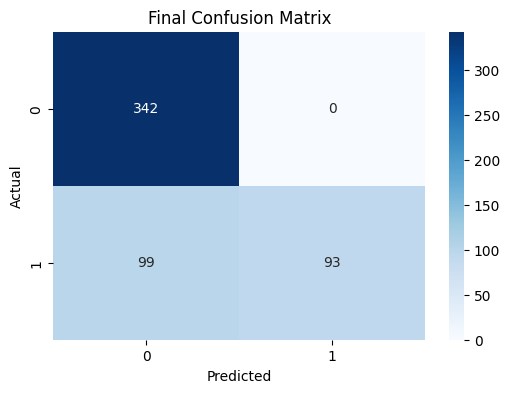

In [ ]:
from sklearn.metrics import confusion_matrix
best_model = grid_search.best_estimator_
y_pred = best_model.predict(X_test)

print("--- Final Model Evaluation Metrics ---")
print(f"Test Accuracy: {accuracy_score(y_test, y_pred):.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred))


cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Final Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

# Web Interface with **Gradio** bold text

In [ ]:
import gradio as gr
import pandas as pd
import numpy as np


def predict_water_safety(ph, Hardness, Solids, Chloramines, Sulfate,
                         Conductivity, Organic_carbon, Trihalomethanes, Turbidity):


    input_data = pd.DataFrame([[ph, Hardness, Solids, Chloramines, Sulfate,
                                Conductivity, Organic_carbon, Trihalomethanes, Turbidity]],
                              columns=['ph', 'Hardness', 'Solids', 'Chloramines', 'Sulfate',
                                       'Conductivity', 'Organic_carbon', 'Trihalomethanes', 'Turbidity'])


    prediction = best_model.predict(input_data)[0]


    if prediction == 1:
        return " The water is Potable."
    else:
        return "The water is Not Potable."


interface = gr.Interface(
    fn=predict_water_safety,
    inputs=[
        gr.Number(label="pH Level", value=7.0),
        gr.Number(label="Hardness (mg/L)", value=196.0),
        gr.Number(label="Solids (ppm)", value=22000.0),
        gr.Number(label="Chloramines (ppm)", value=7.0),
        gr.Number(label="Sulfate (mg/L)", value=333.0),
        gr.Number(label="Conductivity (μS/cm)", value=426.0),
        gr.Number(label="Organic Carbon (ppm)", value=14.0),
        gr.Number(label="Trihalomethanes (μg/L)", value=66.0),
        gr.Number(label="Turbidity (NTU)", value=3.9)
    ],
    outputs=gr.Textbox(label="Prediction Result"),
    title=" Water Potability Prediction System",
    description="Enter the chemical properties of water to check if it is safe for human consumption.",
    theme="soft"
)


interface.launch()

It looks like you are running Gradio on a hosted Jupyter notebook, which requires `share=True`. Automatically setting `share=True` (you can turn this off by setting `share=False` in `launch()` explicitly).

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://d43d50c40d3c10e236.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
